 # Test I Multi-Class Classification of Gravitational Lensing Images
## ML4Sci DeepLense GSoC 2026
**Author:** Krishna (Bala Muralikrishna Durukunala)  
**University:** Robert Morris University, MS in Artificial Intelligence

### My approach
Coming from an ECE background i am used to thinking about images as signals.
Lensing images have both local texture patterns and global structural features.
So instead of using a plain CNN i decided to go with a hybrid approach that 
can capture both — local features through convolutions and global dependencies 
through attention. This is why i picked EfficientViT over the more common 
ResNet or EfficientNet choices.

In [5]:
# basic imports
# coming from data analyst background i always start by 
# understanding the data before touching any model
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device im using:", device)
print("torch version:", torch.__version__)

device im using: cpu
torch version: 2.10.0+cpu


## Step 1Understanding the Data
Before building any model i want to first look at what these 
lensing images actually look like. They are stored as .npy files 
which i havent worked with much before so lets explore them first.

In [6]:
# setting up data paths
# my folder structure is data/test1/dataset/train and val
data_root = Path("data/test1/dataset")

train_dir = data_root / "train"
val_dir = data_root / "val"

# the 3 classes i found when i unzipped the dataset
class_names = ['no', 'sphere', 'vort']

# lets just count how many images we have per class
print("=== Dataset Overview ===")
for split in ['train', 'val']:
    print(f"\n{split} set:")
    for cls in class_names:
        folder = data_root / split / cls
        count = len(list(folder.glob('*.npy')))
        print(f"  {cls}: {count} images")

=== Dataset Overview ===

train set:
  no: 10000 images
  sphere: 10000 images
  vort: 10000 images

val set:
  no: 2500 images
  sphere: 2500 images
  vort: 2500 images


## Step 2 Visualizing the Images
i want to see what each class actually looks like before modeling.
as someone from ECE background i know that understanding your 
signal data visually is really important before doing anything else.

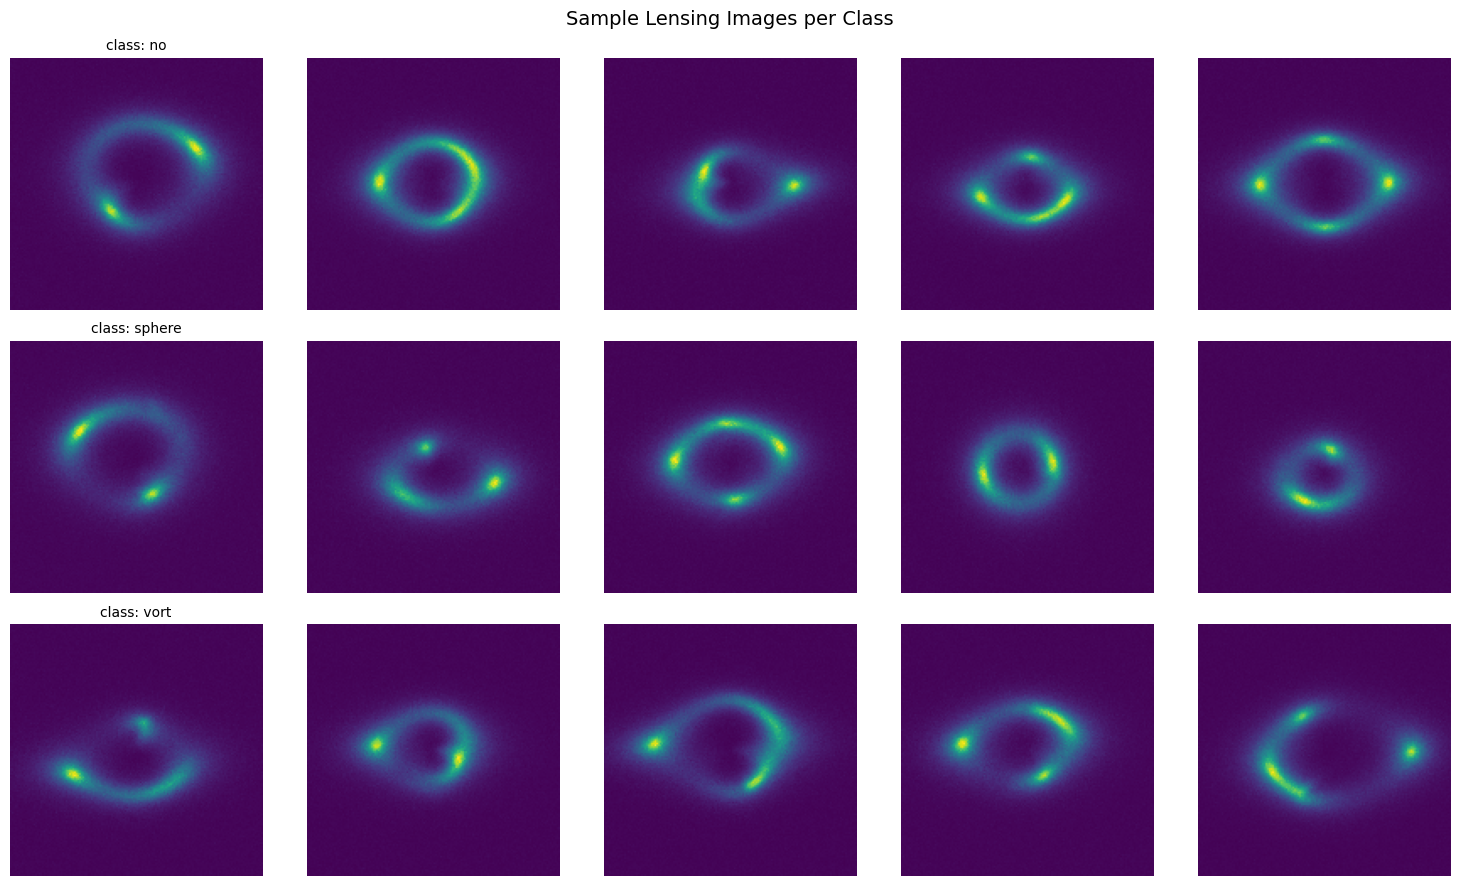

image shape: (1, 150, 150)


In [7]:
# lets visualize some sample images from each class
# i want to see if the 3 classes look visually different to human eye too

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Lensing Images per Class', fontsize=14)

for row, cls in enumerate(class_names):
    cls_folder = train_dir / cls
    sample_files = list(cls_folder.glob('*.npy'))[:5]
    
    for col, fpath in enumerate(sample_files):
        img = np.load(fpath)
        
        # some npy files have shape (1, H, W) so lets squeeze
        if img.ndim == 3:
            img = img.squeeze()
            
        axes[row, col].imshow(img, cmap='viridis')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'class: {cls}', fontsize=10)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print("image shape:", np.load(sample_files[0]).shape)

## Step 3 Building the Dataset Class
images are single channel (1, 150, 150) numpy arrays.
i need to build a custom PyTorch Dataset to load these .npy files.
i will also add some basic augmentations for training to help 
the model generalize better.

In [9]:
# custom dataset class for loading .npy lensing images
class LensingDataset(Dataset):
    def __init__(self, root_dir, class_names, transform=None):
        self.samples = []
        self.transform = transform
        self.class_names = class_names
        
        # go through each class folder and collect file paths + labels
        for label, cls in enumerate(class_names):
            cls_folder = Path(root_dir) / cls
            for fpath in cls_folder.glob('*.npy'):
                self.samples.append((fpath, label))
        
        print(f"loaded {len(self.samples)} samples from {root_dir}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        
        # load numpy array and squeeze channel dim
        img = np.load(fpath).astype(np.float32)
        if img.ndim == 3:
            img = img.squeeze(0)  # now shape is (150, 150)
        
        # convert to tensor and add channel back → (1, 150, 150)
        img = torch.tensor(img).unsqueeze(0)
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

# augmentations for training
# keeping it simple - just flips and small rotations
# dont want to distort the lensing structure too much
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
])

# no augmentation for val
val_transform = None

# create datasets
train_dataset = LensingDataset(train_dir, class_names, transform=train_transform)
val_dataset = LensingDataset(val_dir, class_names, transform=val_transform)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"\ntrain batches: {len(train_loader)}")
print(f"val batches: {len(val_loader)}")

# quick sanity check
sample_img, sample_label = train_dataset[0]
print(f"\nsample image shape: {sample_img.shape}")
print(f"sample label: {sample_label} ({class_names[sample_label]})")

loaded 30000 samples from data\test1\dataset\train
loaded 7500 samples from data\test1\dataset\val

train batches: 469
val batches: 118

sample image shape: torch.Size([1, 150, 150])
sample label: 0 (no)


step 3 building the model

so i was thinking what model to use for this. most people will use resnet 
or efficientnet but i want to try something diffrent. since i studied signals 
in my ECE i know that images have both local patterns and global patterns. 
so i decided to use efficientvit which uses both convolution and attention. 
convolution will catch local lensing features and attention will catch the 
global structure of the galaxy. lets see if this works better.

In [10]:
import timm

# i chose efficientvit because it combines cnn and attention
# normal resnet only does local features but lensing images 
# have global patterns too so attention should help
# also efficientvit is lighter than full vit which is good for cpu

lensing_model = timm.create_model(
    'efficientvit_b0',  
    pretrained=True,    
    num_classes=3,      # we have 3 classes no sphere vort
    in_chans=1          # our images are single channel not rgb
)

lensing_model = lensing_model.to(device)

# lets count how many parameters this model has
total_params = sum(p.numel() for p in lensing_model.parameters())
trainable = sum(p.numel() for p in lensing_model.parameters() if p.requires_grad)
print("total parameters:", total_params)
print("trainable parameters:", trainable)

# quick test to see if model works with our image size
test_input = torch.randn(2, 1, 150, 150).to(device)
test_out = lensing_model(test_input)
print("test output shape:", test_out.shape)
print("model seems to be working fine")

model.safetensors:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

total parameters: 2132707
trainable parameters: 2132707
test output shape: torch.Size([2, 3])
model seems to be working fine


step 4 training setup

now i need to setup the loss function and optimizer. i am using 
crossentropy loss because this is a multiclass problem we have 3 classes.
for optimizer i will use adam because it works well most of the times
i also added a learning rate scheduler to reduce lr when model stops improving
i read about this in one of the papers and thought to try it here


In [12]:
# loss and optimizer setup
# crossentropy is standard for multiclass classification
criterion = nn.CrossEntropyLoss()

# adam optimizer i kept lr small because pretrained model
# if lr is too high it will mess up the pretrained weights
adam_opt = optim.Adam(lensing_model.parameters(), lr=0.0001)

# reduce lr if val loss stops improving
# patience 3 means wait 3 epochs before reducing
# removed verbose=True because new pytorch version doesnt support it
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    adam_opt, 
    mode='min',
    patience=3,
    factor=0.5
)

print("criterion:", criterion)
print("optimizer:", adam_opt)
print("scheduler ready")

criterion: CrossEntropyLoss()
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
scheduler ready


step 5 training loop

now i will write the training loop. i will train for 10 epochs 
and save the best model based on validation loss. i also want to 
track accuracy and loss for both train and val so i can plot them 
later and see if model is overfitting or not. this is something 
i learned from my data analyst days always monitor your metrics

In [ ]:
# training loop
# i am saving best model weights based on val loss
# also tracking history to plot later

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f"  batch {batch_idx}/{len(loader)} loss: {loss.item():.4f}")
    
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


# training starts here
num_epochs = 10
best_val_loss = float('inf')
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("starting training...")
print("="*50)

for epoch in range(num_epochs):
    print(f"\nepoch {epoch+1}/{num_epochs}")
    
    train_loss, train_acc = train_one_epoch(
        lensing_model, train_loader, criterion, adam_opt
    )
    val_loss, val_acc = evaluate(
        lensing_model, val_loader, criterion
    )
    
    lr_scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(lensing_model.state_dict(), 'best_model_test1.pth')
        print(f"  model saved!")
    
    print(f"  train loss: {train_loss:.4f} | train acc: {train_acc:.4f}")
    print(f"  val loss:   {val_loss:.4f} | val acc:   {val_acc:.4f}")

print("\ntraining done!")

starting training...

epoch 1/10
  batch 0/469 loss: 1.1601
